# Evaluation of Feature Extraction Experiments

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load results

In [ ]:
BASE_DIR = Path("..") / "results" / "03_Extracted_Features_Aggregated_Files"

In [3]:
df_bosch_cnc = pd.read_csv(BASE_DIR / "Bosch_CNC.csv", sep=";", decimal=",")
df_bosch_cnc["dataset"] = "Bosch_CNC"
df_bosch_cnc["sampling_frequency"] = 2000

df_turning = pd.read_csv(BASE_DIR / "Turning_Dataset.csv", sep=";", decimal=",")
df_turning["dataset"] = "Turning_Dataset"
df_turning["sampling_frequency"] = 10000

df_cmohs = pd.read_csv(BASE_DIR / "Condition_Monitoring_of_Hydraulic_Systems.csv", sep=";", decimal=",")
df_cmohs["dataset"] = "Condition_Monitoring_of_Hydraulic_Systems"
df_cmohs["sampling_frequency"] = 100

df_cnc_mill = pd.read_csv(BASE_DIR / "CNC_Mill_Tool_Wear.csv", sep=";", decimal=",")
df_cnc_mill["dataset"] = "CNC_Mill_Tool_Wear"
df_cnc_mill["sampling_frequency"] = 10

In [4]:
df_all = pd.concat([df_bosch_cnc, df_turning, df_cmohs, df_cnc_mill], axis="index", ignore_index=True)

In [5]:
# Replace NaN values with 0
df_all = df_all.fillna("")

In [6]:
df_all["package_name"] = df_all["package"] + "_" + df_all["configuration"]

In [7]:
df_all["multiprocessing"] = df_all["package_name"].str.contains("60|kats")

In [8]:
df_all["total_samples"] = df_all["num_samples"] * df_all["time_series_per_sample"]

## Barplot per Package

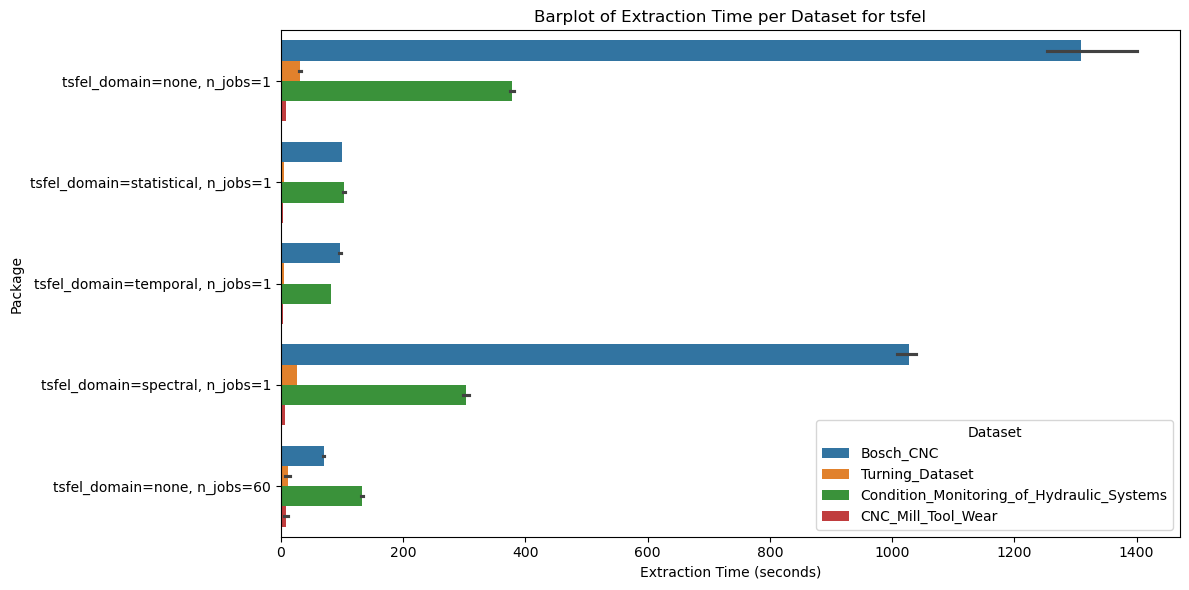

In [9]:
package = "tsfel"
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_all[df_all["package"] == package],
    y="package_name",
    x="execution_time",
    hue="dataset",
)
plt.title(f"Barplot of Extraction Time per Dataset for {package}")
plt.xlabel("Extraction Time (seconds)")
plt.ylabel("Package")
plt.tight_layout()
plt.legend(title="Dataset")
plt.show()

## Boxplot per Dataset

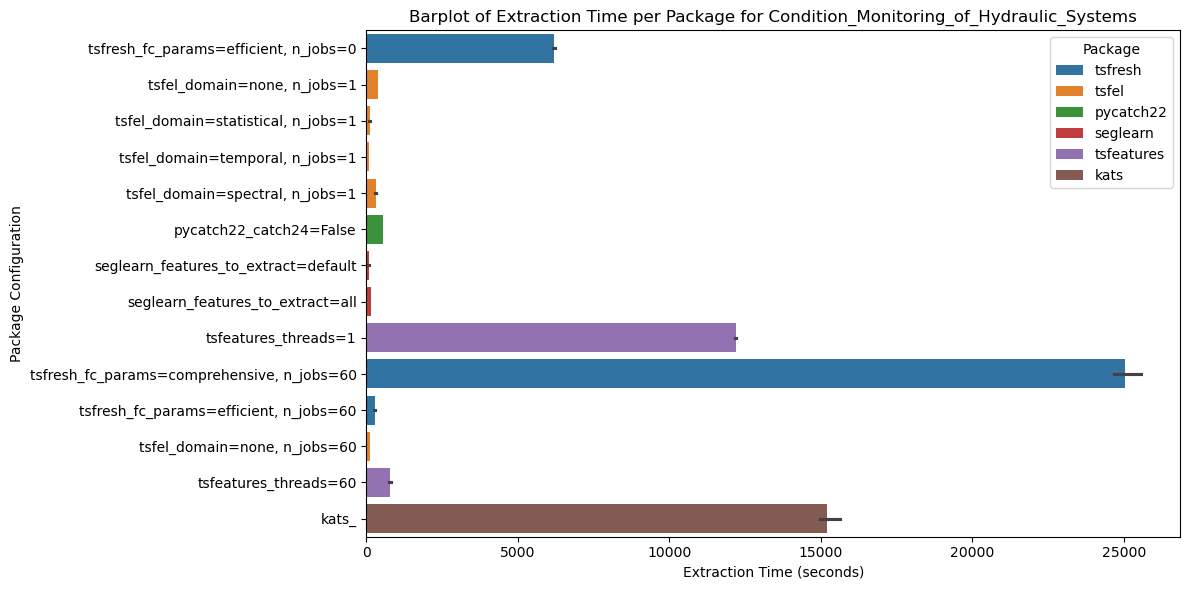

In [10]:
dataset = "Condition_Monitoring_of_Hydraulic_Systems"
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_all[df_all["dataset"] == dataset],
    y="package_name",
    x="execution_time",
    hue="package",
)
plt.title(f"Barplot of Extraction Time per Package for {dataset}")
plt.xlabel("Extraction Time (seconds)")
plt.ylabel("Package Configuration")
plt.tight_layout()
plt.legend(title="Package")
plt.show()

## Scatter plot showing extraction_time vs. number of extracted features

## Memory vs. Execution Time

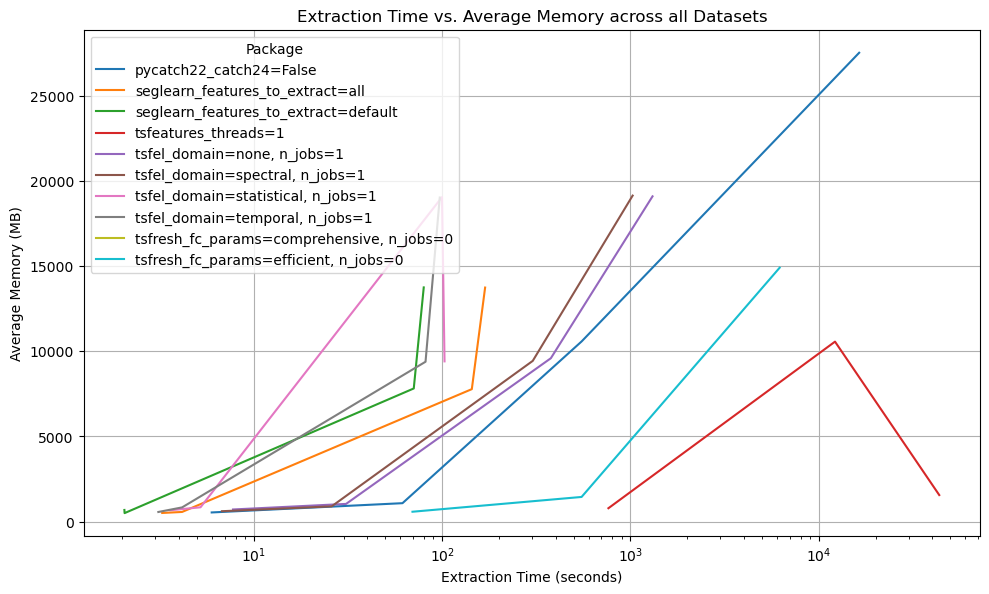

In [11]:
df_plot = df_all.groupby(["package_name", "dataset"])[["execution_time", "average_memory"]].mean().reset_index()

df_plot = df_plot[~df_plot["package_name"].str.contains("60|kats")] # Single processing packages
# df_plot = df_plot[df_plot["package_name"].str.contains("60|kats")] # Multi processing packages

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot,
    x="execution_time",
    y="average_memory",
    hue="package_name",
)
plt.title("Extraction Time vs. Average Memory across all Datasets")
plt.xlabel("Extraction Time (seconds)")
plt.ylabel("Average Memory (MB)")
plt.tight_layout()
plt.legend(title="Package")
plt.grid()
plt.xscale("log")
# plt.yscale("log")
plt.show()

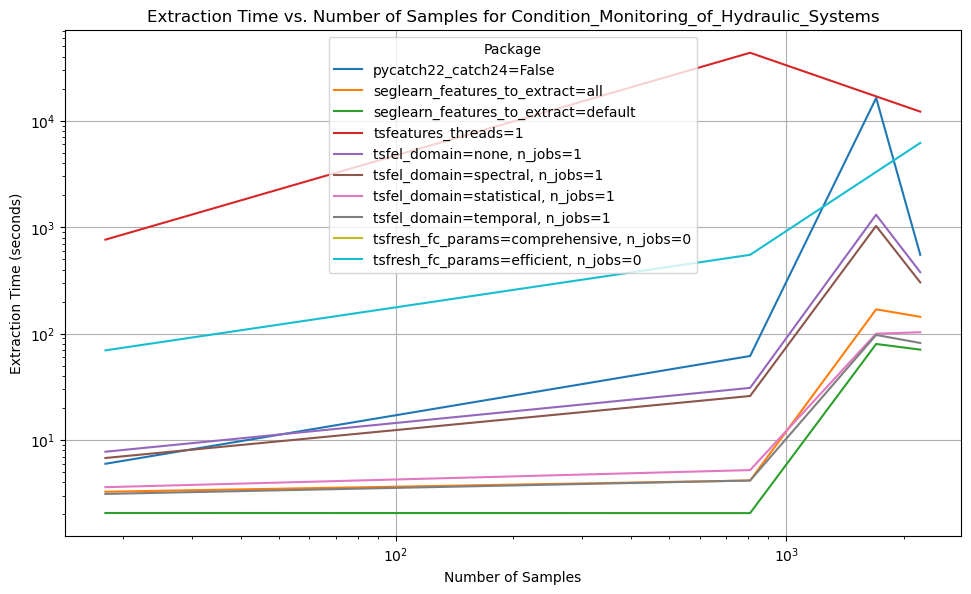

In [12]:
df_plot = df_all.groupby(["package_name", "dataset"])[["num_samples", "execution_time"]].mean().reset_index()

df_plot = df_plot[~df_plot["package_name"].str.contains("60|kats")] # Single processing packages
# df_plot = df_plot[df_plot["package_name"].str.contains("60|kats")] # Multi processing packages

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot,
    x="num_samples",
    y="execution_time",
    hue="package_name",
)
plt.title(f"Extraction Time vs. Number of Samples for {dataset}")
plt.xlabel("Number of Samples")
plt.ylabel("Extraction Time (seconds)")
plt.tight_layout()
plt.legend(title="Package")
plt.grid()
plt.xscale("log")
plt.yscale("log")
plt.show()

## Barplots of Execution Time, Memory and CPU Load

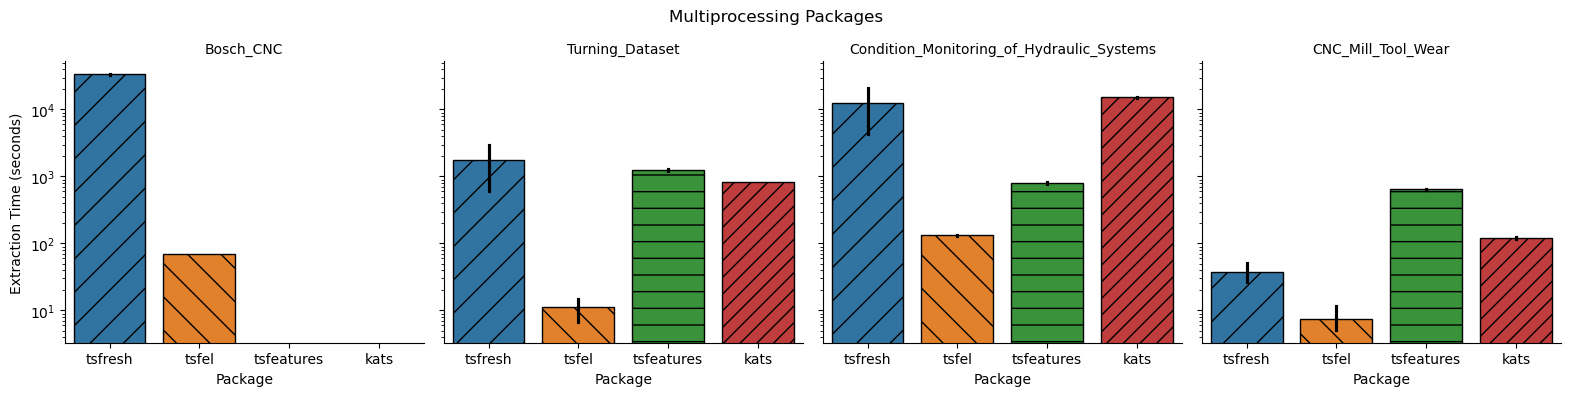

In [13]:
# df_plot = df_all[~df_all["package_name"].str.contains("60|kats")] # Single processing packages
df_plot = df_all[df_all["package_name"].str.contains("60|kats")] # Multi processing packages


g = sns.catplot(
    data=df_plot,
    x="package",
    y="execution_time",
    col="dataset",
    kind="bar",
    hue="package",
    height=4,
    aspect=1,
    edgecolor="black",
    err_kws={'color': 'black'},
)
g.set_axis_labels("Package", "Extraction Time (seconds)")
g.set_titles("{col_name}")
g.figure.subplots_adjust(top=0.85) # adjust the Figure in rp
g.figure.suptitle("Multiprocessing Packages")
    
# Add hatches to the bars
hatches = ['/', '\\', '-', '//', '\\\\']
for ax in g.axes.flat:
    for i, bar in enumerate(ax.patches):
        bar.set_hatch(hatches[i])

plt.yscale("log")

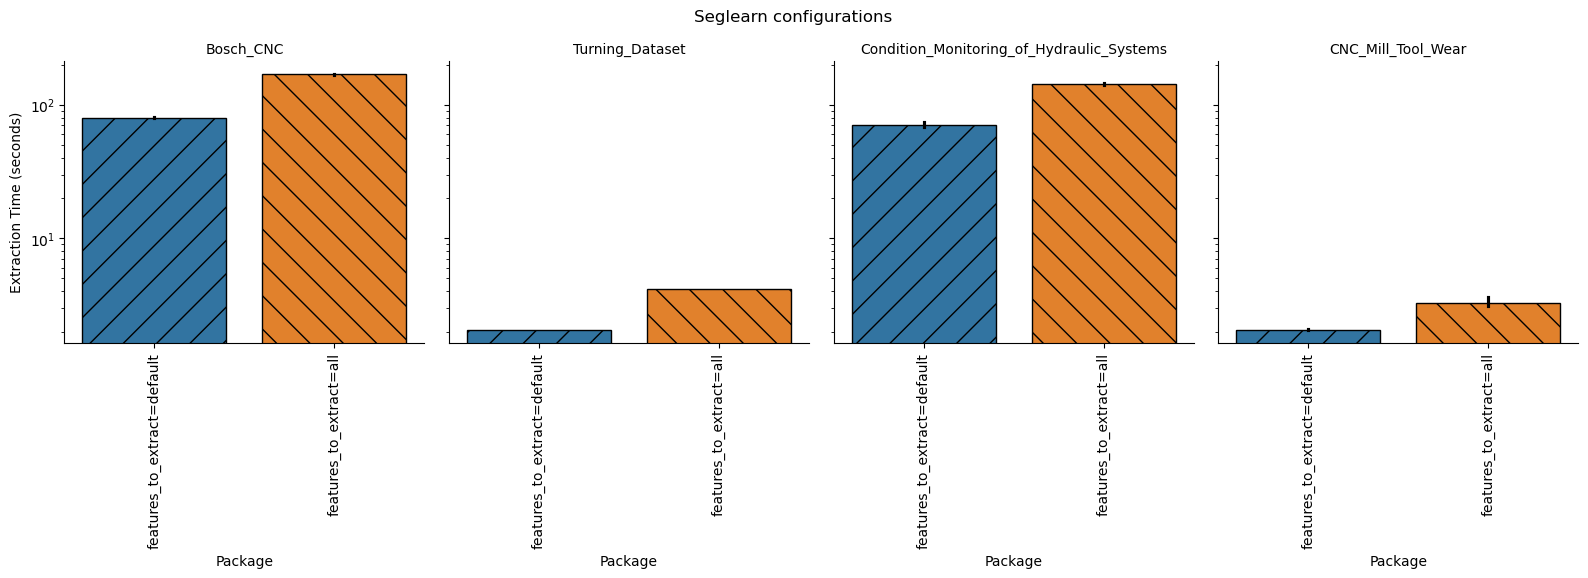

In [14]:
df_plot = df_all[df_all["package"] == "seglearn"]

g = sns.catplot(
    data=df_plot,
    x="configuration",
    y="execution_time",
    col="dataset",
    kind="bar",
    hue="configuration",
    height=4,
    aspect=1,
    edgecolor="black",
    err_kws={'color': 'black'},
)
g.set_axis_labels("Package", "Extraction Time (seconds)")
g.set_xticklabels(rotation=90)
g.set_titles("{col_name}")
g.figure.subplots_adjust(top=0.85) # adjust the Figure in rp
g.figure.suptitle("Seglearn configurations")
    
# Add hatches to the bars
hatches = ['/', '\\', '-', '//', '\\\\']
for ax in g.axes.flat:
    for i, bar in enumerate(ax.patches):
        bar.set_hatch(hatches[i])

plt.yscale("log")

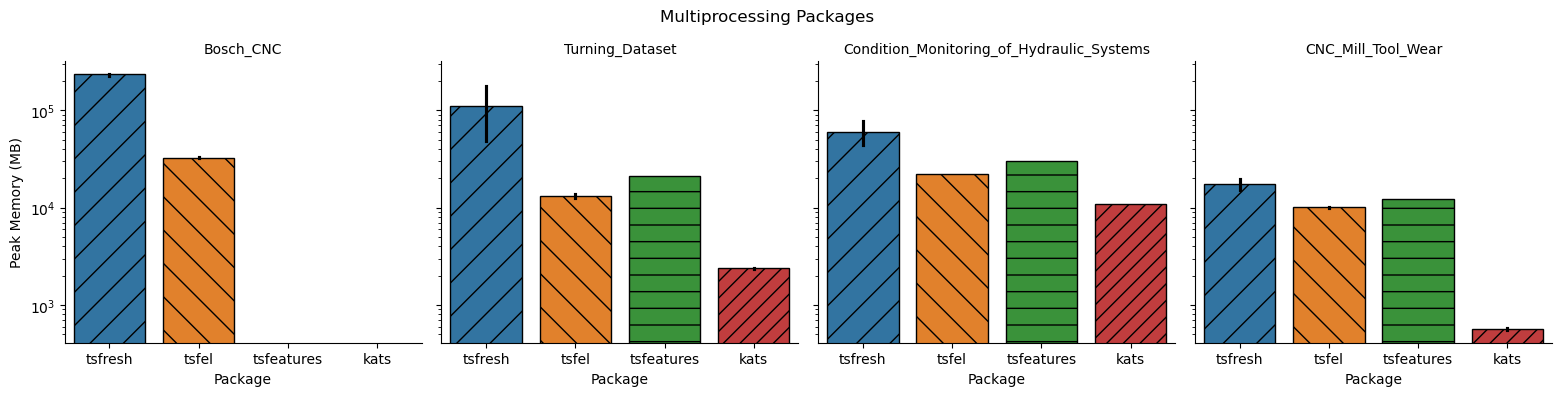

In [15]:
# df_plot = df_all[~df_all["package_name"].str.contains("60|kats")] # Single processing packages
df_plot = df_all[df_all["package_name"].str.contains("60|kats")] # Multi processing packages


g = sns.catplot(
    data=df_plot,
    x="package",
    y="peak_memory",
    col="dataset",
    kind="bar",
    hue="package",
    height=4,
    aspect=1,
    edgecolor="black",
    err_kws={'color': 'black'},
)
g.set_axis_labels("Package", "Peak Memory (MB)")
g.set_titles("{col_name}")
g.figure.subplots_adjust(top=0.85) # adjust the Figure in rp
g.figure.suptitle("Multiprocessing Packages")
    
# Add hatches to the bars
hatches = ['/', '\\', '-', '//', '\\\\']
for ax in g.axes.flat:
    for i, bar in enumerate(ax.patches):
        bar.set_hatch(hatches[i])

plt.yscale("log")

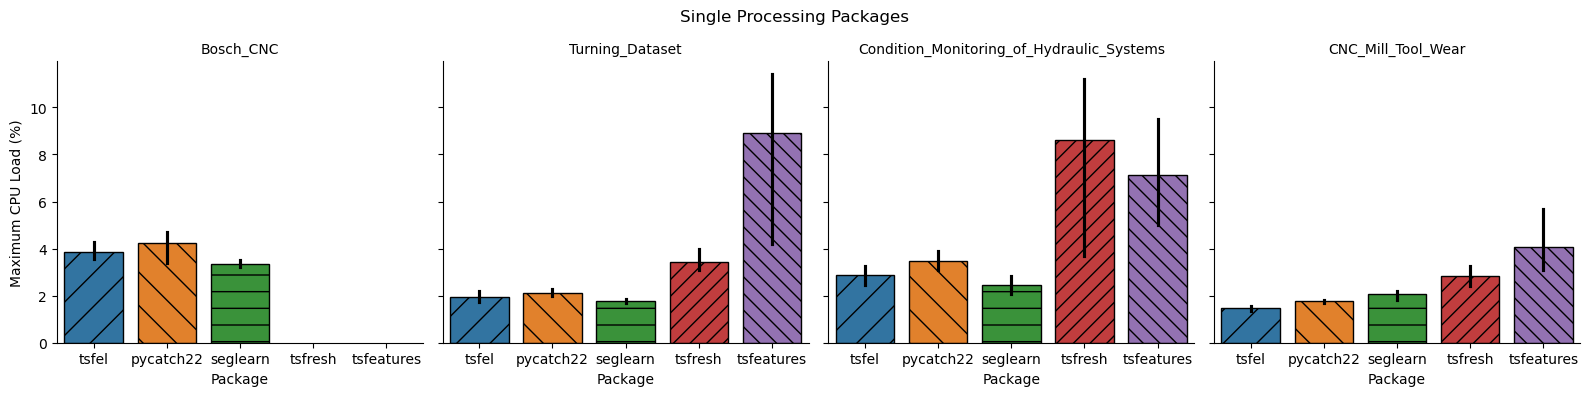

In [16]:
df_plot = df_all[~df_all["package_name"].str.contains("60|kats")] # Single processing packages
# df_plot = df_all[df_all["package_name"].str.contains("60|kats")] # Multiprocessing packages

g = sns.catplot(
    data=df_plot,
    x="package",
    y="max_cpu_load",
    col="dataset",
    kind="bar",
    hue="package",
    height=4,
    aspect=1,
    edgecolor="black",
    err_kws={'color': 'black'},
)
g.set_axis_labels("Package", "Maximum CPU Load (%)")
g.set_titles("{col_name}")
g.figure.subplots_adjust(top=0.85) # adjust the Figure in rp
g.figure.suptitle("Single Processing Packages")
    
# Add hatches to the bars
hatches = ['/', '\\', '-', '//', '\\\\']
for ax in g.axes.flat:
    for i, bar in enumerate(ax.patches):
        bar.set_hatch(hatches[i])

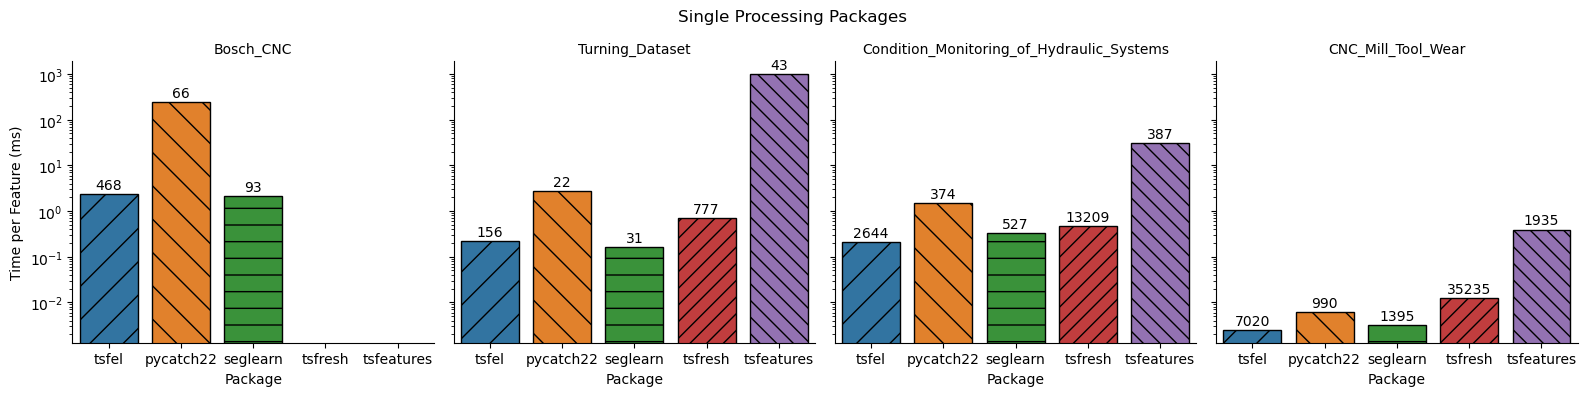

In [17]:
df_plot = df_all[~df_all["package_name"].str.contains("60|kats")].copy() # Single processing packages
# df_plot = df_all[df_all["package_name"].str.contains("60|kats")].copy() # Multiprocessing packages

df_plot["time_per_feature"] = df_plot["execution_time"] / df_plot["extracted_features"]

g = sns.catplot(
    data=df_plot,
    x="package",
    y="time_per_feature",
    col="dataset",
    kind="bar",
    hue="package",
    height=4,
    aspect=1,
    edgecolor="black",
    err_kws={'color': 'black'},
    errorbar=None,
)
g.set_axis_labels("Package", "Time per Feature (ms)")
g.set_titles("{col_name}")
g.figure.subplots_adjust(top=0.85) # adjust the Figure in rp
g.figure.suptitle("Single Processing Packages")
    
# Add hatches to the bars
hatches = ['/', '\\', '-', '//', '\\\\']
for ax in g.axes.flat:
    for i, bar in enumerate(ax.patches):
        bar.set_hatch(hatches[i])


# Add label above each bar
datasets = ["Bosch_CNC", "Turning_Dataset", "Condition_Monitoring_of_Hydraulic_Systems", "CNC_Mill_Tool_Wear"]
packages = df_plot["package"].unique()
for dataset, ax in zip(datasets, g.axes.flat):
    df_dataset = df_plot[df_plot["dataset"] == dataset]
    for i, bar in enumerate(ax.patches):
        df_package = df_dataset[df_dataset["package"] == packages[i]]
        # Add label above each bar
        extracted_features = df_package["extracted_features"].max()
        ax.text(
            bar.get_x() + bar.get_width() / 2,     # X position
            bar.get_height() / 0.9,                # Y position (top of the bar)
            f'{extracted_features}',               # Label text
            ha='center',                           # Horizontal alignment
            va='bottom'                            # Vertical alignment
        )

plt.yscale("log")

## Lineplots

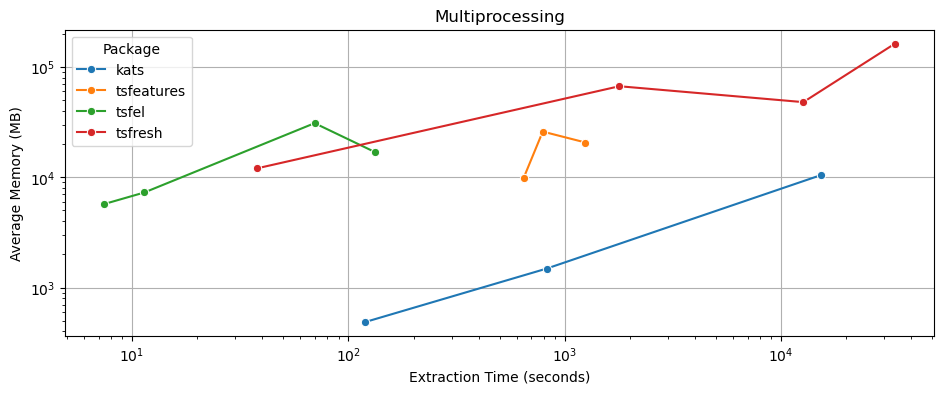

In [18]:
# Single Processing:
# df_plot = df_all[~df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "average_memory"]].mean().reset_index()

# # Multiprocessing:
df_plot = df_all[df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "average_memory"]].mean().reset_index()

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=df_plot,
    x="execution_time",
    y="average_memory",
    hue="package",
    marker="o",
)
plt.title("Multiprocessing")
plt.xlabel("Extraction Time (seconds)")
plt.ylabel("Average Memory (MB)")
plt.tight_layout()
plt.legend(title="Package")
plt.grid()
plt.xscale("log")
plt.yscale("log")
plt.show()

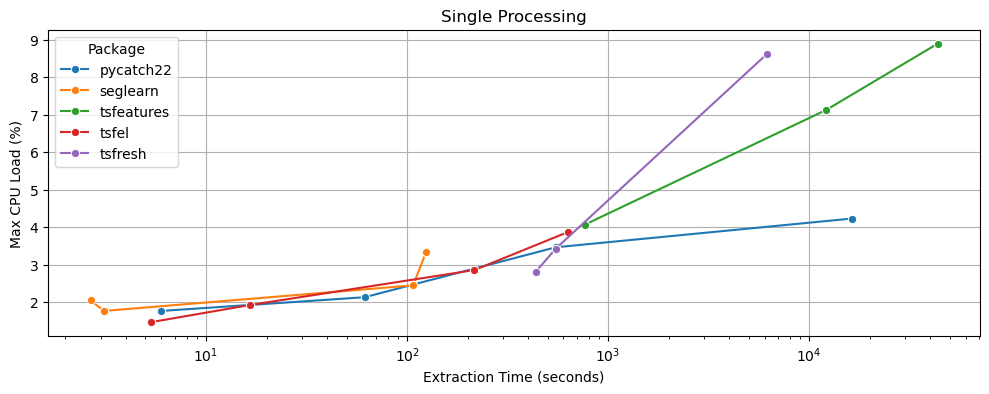

In [19]:
# Single Processing:
df_plot = df_all[~df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "max_cpu_load"]].mean().reset_index()

# # Multiprocessing:
# df_plot = df_all[df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "max_cpu_load"]].mean().reset_index()

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=df_plot,
    x="execution_time",
    y="max_cpu_load",
    hue="package",
    marker="o",
)
plt.title("Single Processing")
plt.xlabel("Extraction Time (seconds)")
plt.ylabel("Max CPU Load (%)")
plt.tight_layout()
plt.legend(title="Package")
plt.grid()
plt.xscale("log")
# plt.yscale("log")
plt.show()

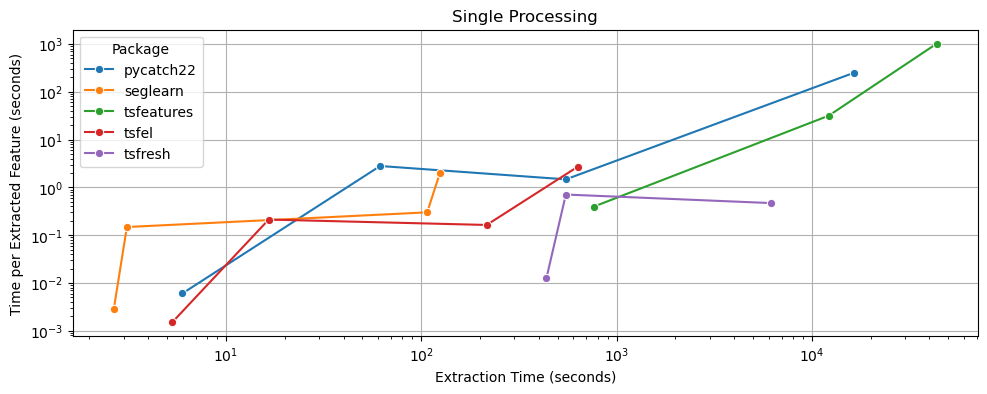

In [20]:
# Single Processing:
df_plot = df_all[~df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "extracted_features"]].mean().reset_index()

# # Multiprocessing:
# df_plot = df_all[df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "extracted_features"]].mean().reset_index()

df_plot["time_per_feature"] = df_plot["execution_time"] / df_plot["extracted_features"]

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=df_plot,
    x="execution_time",
    y="time_per_feature",
    hue="package",
    marker="o",
)
plt.title("Single Processing")
plt.xlabel("Extraction Time (seconds)")
plt.ylabel("Time per Extracted Feature (seconds)")
plt.tight_layout()
plt.legend(title="Package")
plt.grid()
plt.xscale("log")
plt.yscale("log")
plt.show()

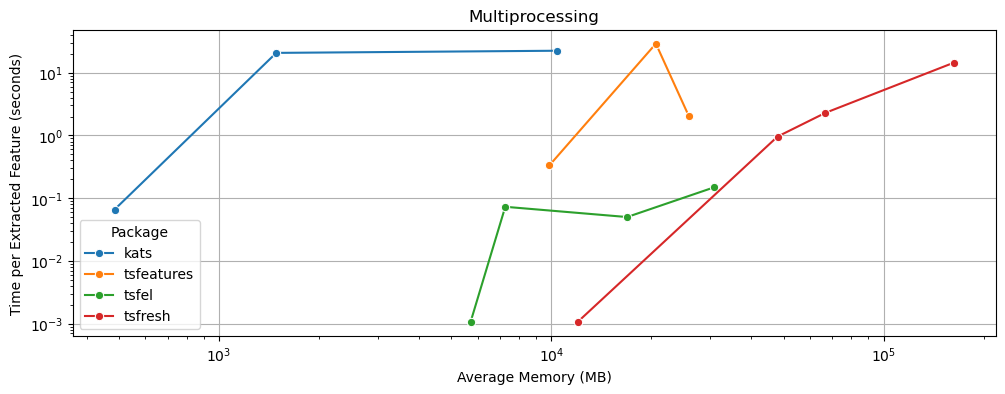

In [21]:
# Single Processing:
# df_plot = df_all[~df_all["multiprocessing"]].groupby(["package", "dataset"])[["average_memory", "execution_time", "extracted_features"]].mean().reset_index()

# # Multiprocessing:
df_plot = df_all[df_all["multiprocessing"]].groupby(["package", "dataset"])[["average_memory", "execution_time", "extracted_features"]].mean().reset_index()

df_plot["time_per_feature"] = df_plot["execution_time"] / df_plot["extracted_features"]

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=df_plot,
    x="average_memory",
    y="time_per_feature",
    hue="package",
    marker="o",
)
plt.title("Multiprocessing")
plt.xlabel("Average Memory (MB)")
plt.ylabel("Time per Extracted Feature (seconds)")
plt.tight_layout()
plt.legend(title="Package")
plt.grid()
plt.xscale("log")
plt.yscale("log")
plt.show()

### Execution Time pro Merkmal

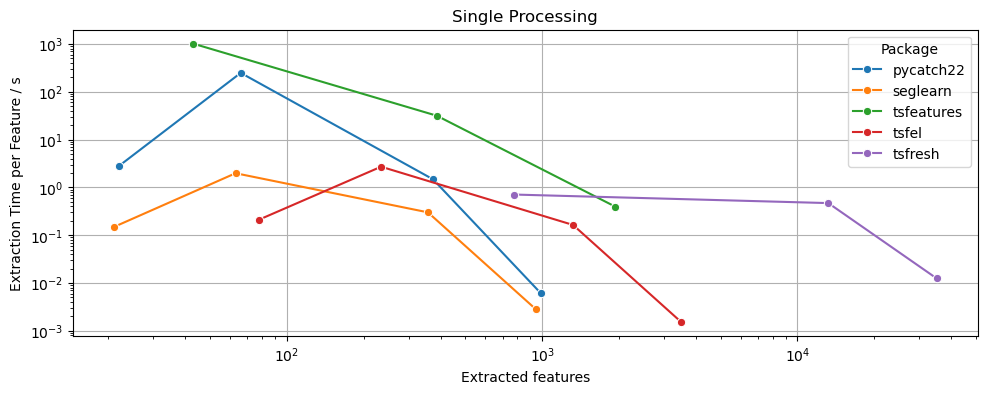

In [52]:
# Single Processing:
df_plot = df_all[~df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "extracted_features"]].mean().reset_index()

# # Multiprocessing:
# df_plot = df_all[df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "extracted_features"]].mean().reset_index()

df_plot["time_per_feature"] = df_plot["execution_time"] / df_plot["extracted_features"]

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=df_plot,
    y="time_per_feature",
    x="extracted_features",
    hue="package",
    marker="o",
)
plt.title("Single Processing")
plt.ylabel("Extraction Time per Feature / s")
plt.xlabel("Extracted features")
plt.tight_layout()
plt.legend(title="Package")
plt.grid()
plt.xscale("log")
plt.yscale("log")
plt.show()

### Execution Time pro Merkmal pro Sample

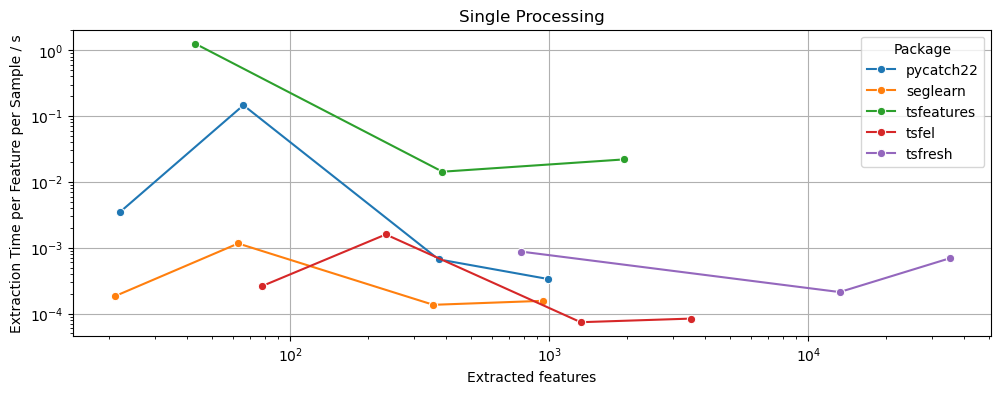

In [45]:
# Single Processing:
df_plot = df_all[~df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "extracted_features", "num_samples"]].mean().reset_index()

# # Multiprocessing:
# df_plot = df_all[df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "extracted_features", "num_samples"]].mean().reset_index()

df_plot["time_per_feature"] = df_plot["execution_time"] / df_plot["extracted_features"] / df_plot["num_samples"]

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=df_plot,
    y="time_per_feature",
    x="extracted_features",
    hue="package",
    marker="o",
)
plt.title("Single Processing")
plt.ylabel("Extraction Time per Feature per Sample / s")
plt.xlabel("Extracted features")
plt.tight_layout()
plt.legend(title="Package")
plt.grid()
plt.xscale("log")
plt.yscale("log")
plt.show()

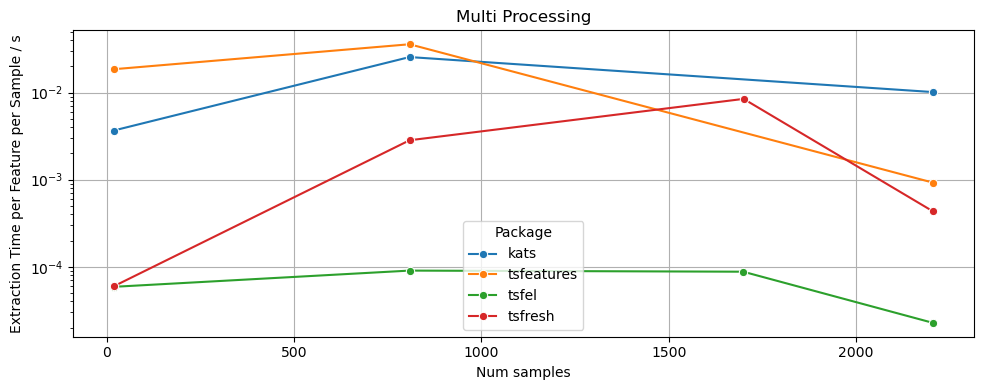

In [55]:
# Single Processing:
# df_plot = df_all[~df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "extracted_features", "num_samples"]].mean().reset_index()

# # Multiprocessing:
df_plot = df_all[df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "extracted_features", "num_samples"]].mean().reset_index()

df_plot["time_per_feature"] = df_plot["execution_time"] / df_plot["extracted_features"] / df_plot["num_samples"]

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=df_plot,
    y="time_per_feature",
    x="num_samples",
    hue="package",
    marker="o",
)
plt.title("Multi Processing")
plt.ylabel("Extraction Time per Feature per Sample / s")
plt.xlabel("Num samples")
plt.tight_layout()
plt.legend(title="Package")
plt.grid()
# plt.xscale("log")
plt.yscale("log")
plt.show()

### Execution Time per Sample

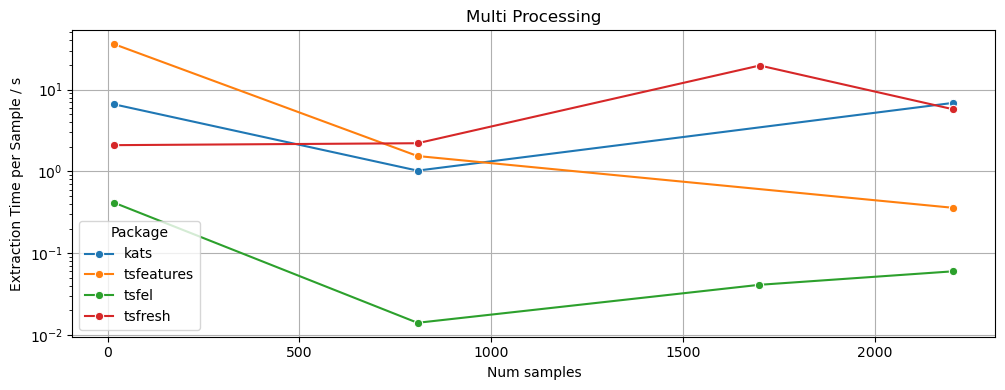

In [59]:
# Single Processing:
# df_plot = df_all[~df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "extracted_features", "num_samples"]].mean().reset_index()

# # Multiprocessing:
df_plot = df_all[df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "extracted_features", "num_samples"]].mean().reset_index()

df_plot["time_per_sample"] = df_plot["execution_time"] / df_plot["num_samples"]

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=df_plot,
    y="time_per_sample",
    x="num_samples",
    hue="package",
    marker="o",
)
plt.title("Multi Processing")
plt.ylabel("Extraction Time per Sample / s")
plt.xlabel("Num samples")
plt.tight_layout()
plt.legend(title="Package")
plt.grid()
# plt.xscale("log")
plt.yscale("log")
plt.show()

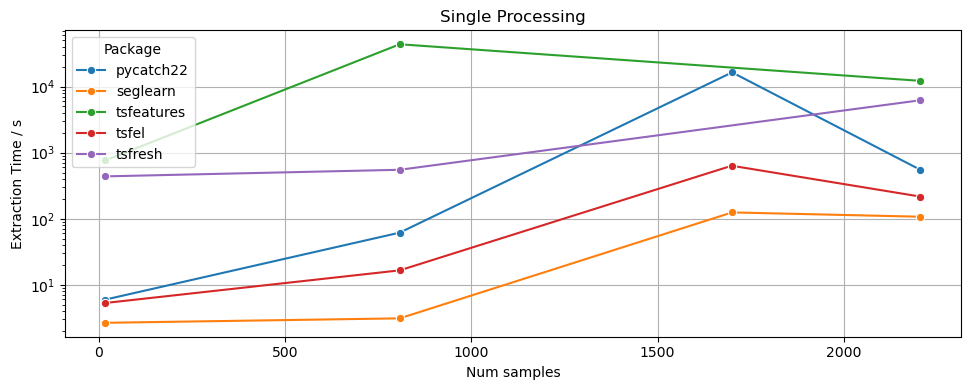

In [61]:
# Single Processing:
df_plot = df_all[~df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "extracted_features", "num_samples"]].mean().reset_index()

# # Multiprocessing:
# df_plot = df_all[df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "extracted_features", "num_samples"]].mean().reset_index()

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=df_plot,
    y="execution_time",
    x="num_samples",
    hue="package",
    marker="o",
)
plt.title("Single Processing")
plt.ylabel("Extraction Time / s")
plt.xlabel("Num samples")
plt.tight_layout()
plt.legend(title="Package")
plt.grid()
# plt.xscale("log")
plt.yscale("log")
plt.show()

### Execution Time by Dataset size

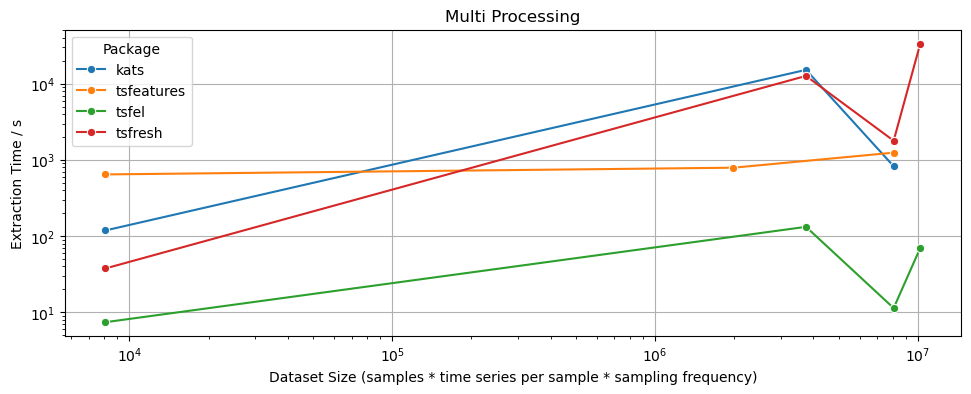

In [71]:
# Single Processing:
# df_plot = df_all[~df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "num_samples", "time_series_per_sample", "sampling_frequency"]].mean().reset_index()

# # Multiprocessing:
df_plot = df_all[df_all["multiprocessing"]].groupby(["package", "dataset"])[["execution_time", "num_samples", "time_series_per_sample", "sampling_frequency"]].mean().reset_index()

df_plot["ds_size"] = df_plot["num_samples"] * df_plot["time_series_per_sample"] * df_plot["sampling_frequency"]

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=df_plot,
    y="execution_time",
    x="ds_size",
    hue="package",
    marker="o",
)
plt.title("Multi Processing")
plt.ylabel("Extraction Time / s")
plt.xlabel("Dataset Size (samples * time series per sample * sampling frequency)")
plt.tight_layout()
plt.legend(title="Package")
plt.grid()
plt.xscale("log")
plt.yscale("log")
plt.show()

In [63]:
df_all

,package,configuration,run,execution_time,max_cpu_load,average_cpu_load,peak_memory,average_memory,num_samples,time_series_per_sample,extracted_features,dataset,sampling_frequency,package_name,multiprocessing,total_samples
0,tsfel,"domain=none, n_jobs=1",1,1253.781905,4.3,1.823711,19124.082030,19093.326570,1699,3,468,Bosch_CNC,2000,"tsfel_domain=none, n_jobs=1",False,5097
1,tsfel,"domain=none, n_jobs=1",2,1273.283130,4.0,1.771650,19118.675780,19086.730500,1699,3,468,Bosch_CNC,2000,"tsfel_domain=none, n_jobs=1",False,5097
2,tsfel,"domain=none, n_jobs=1",3,1400.996524,3.7,1.848404,19110.589840,19080.650400,1699,3,468,Bosch_CNC,2000,"tsfel_domain=none, n_jobs=1",False,5097
3,tsfel,"domain=statistical, n_jobs=1",1,100.492633,4.2,1.819271,19169.218750,19054.818910,1699,3,93,Bosch_CNC,2000,"tsfel_domain=statistical, n_jobs=1",False,5097
4,tsfel,"domain=statistical, n_jobs=1",2,99.280257,3.0,1.742708,19140.718750,19040.040340,1699,3,93,Bosch_CNC,2000,"tsfel_domain=statistical, n_jobs=1",False,5097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,tsfeatures,threads=60,2,636.184615,62.6,18.932772,12173.195310,9932.791050,18,45,1935,CNC_Mill_Tool_Wear,10,tsfeatures_threads=60,True,810
152,tsfeatures,threads=60,3,643.660560,64.4,18.880718,12182.359380,9927.936600,18,45,1935,CNC_Mill_Tool_Wear,10,tsfeatures_threads=60,True,810
153,kats,,1,116.800138,50.6,37.233173,554.804688,464.829853,18,45,1800,CNC_Mill_Tool_Wear,10,kats_,True,810
154,kats,,2,115.089601,50.0,38.086341,583.960938,498.591521,18,45,1800,CNC_Mill_Tool_Wear,10,kats_,True,810
